# 2 state Climate model
This model is based on code for ABC model and uses parameters in my Banque de France course.


In [1]:
# Import necessary libraries
import numpy as np
import math
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import TensorBoard

import matplotlib.pyplot as plt
from matplotlib import rc
plt.rcParams["font.size"] = 15


#only work with cpu
tf.config.set_visible_devices([], 'GPU')


print("Version of tensorflow is {}".format(tf.__version__))

Version of tensorflow is 2.19.0


## Evaluation operator
Calculate probability weights and discrete values (notes) for stochastic shocks.

In [2]:
n_int = 5 # integration nodes
x_int_norm, w_int = np.polynomial.hermite.hermgauss(n_int) # obtain standard GH nodes and weights
w_int = w_int / np.sqrt(np.pi) # divide the weights by sqrt(pi)
x_int_norm = x_int_norm * np.sqrt(2) # multiply weights with 2**0.5

#convert to tensorflow
x_int_norm = tf.constant(x_int_norm, dtype = tf.float32)
w_int = tf.constant(w_int, dtype = tf.float32)


# we should make sure the weights some to 1
print("sum(w_int) = ", np.sum(w_int))
print("weights: ", w_int)
print("Nodes: ", x_int_norm)

sum(w_int) =  1.0000001
weights:  tf.Tensor([0.01125741 0.22207592 0.53333336 0.22207592 0.01125741], shape=(5,), dtype=float32)
Nodes:  tf.Tensor([-2.85697   -1.3556262  0.         1.3556262  2.85697  ], shape=(5,), dtype=float32)


## Model parameters

In [3]:
#PARAMETERS
# preferences
rho=0.006       #utility discount rate reduced by population growth
eta=1.35;       #elasticity of marginal utility wrt consumption

#economic model
g=0.02;         #exogenous growth rate
r=rho+(eta-1)*g #growth adjusted discount rate
sigmaS=0.001;   #standard deviation of Brownian motion on S
alpha=0.3;      #elasticity of capital in Cobb-Douglas from DICE
delta_c=0.1;    #depreciation rate per year
#A=5.115;       #total factor productivity from DICE
#L=7.403;       #popuation from DICE
#K0=223;        #initial capital from DICE

#Abatement costs (emissions in TtCO2)
phi=0.00126*1000;       #MAC intercept
varphi=0.00003*1000**2; #MAC slope
E0=phi/varphi           #BAU emissions

#Climate and damages
zeta=0.0006*1000;   #TCRE in °C per TeratCO2
gammaT=0.01;        #damage as proportion of GDP is exp(0.5*gammaT*T²)
gamma=zeta**2*gammaT; # gamma includes the TCRE
S0=2000/1000;       #initial cumulative emissions


## Neural network architecture

In this section, I define the architecture of the deep neural net.
States are cumulative emissions and capital. They are the input into the NN. The decision variables are investment and emissions, but to be able to use sigmoid function, which stays between 0 and 1, I will use investment over production and emissions over initial emissions as decision variables.

Therefore, the neural network input is a 2-dimensional state $\mathbf{X}_t = [Sx, Kx]$ and the output is the 2-dimensional vector $\mathbf{Y}_t = [Esharey, Isharey]$.

I use 2 hidden layers with 128 nodes each (ad-hoc) with each hidden layer having a relu activation function.  

For the output layer I chose a sigmoid function for the investment share and softplus for emissionshare to ensure nonnegativity.


In [4]:
# Layer setting
num_input = 2
num_hidden1 = 128
num_hidden2 = 128
num_output = 2
layers_dim = [num_input, num_hidden1, num_hidden2, num_output]
print("Dimensions of each layer are {}".format(layers_dim))

Dimensions of each layer are [2, 128, 128, 2]


In [5]:
Inlayer = keras.Input(shape=(num_input,))
hidden1 = keras.layers.Dense(num_hidden1, activation='selu')(Inlayer)
hidden2 = keras.layers.Dense(num_hidden2, activation='selu')(hidden1)
neuronE = keras.layers.Dense(1, activation = "linear")(hidden2)
neuronI = keras.layers.Dense(1, activation = "sigmoid")(hidden2) #even if capital is beyond steady state, investments are positive (but less than depreciation)
outlayer = keras.layers.concatenate([neuronE, neuronI])

nn = keras.Model(inputs=Inlayer, outputs=outlayer)
nn.build(input_shape=(None, num_input))



### Evaluate expectation

In [6]:
@tf.function
def get_singleinside(X_next, nn):
    n_data = X_next.shape[0] # number of states is on the axis 0
    dim_state = X_next.shape[1] # dimensionality of the state is on axis 1

    # read out the state
    Sx_next = X_next[:, 0 : 1]
    Kx_next = X_next[:, 1 : 2]

    # use the neural network to predict E_next and Ky_next
    Y_next = nn(X_next)

    # read out Y
    Esharey_next = Y_next[:, 0 : 1]
    Isharey_next = Y_next[:, 1 : 2]

    # Emissions
    Ey_next=Esharey_next*E0

    # compute output
    Yy_next = Kx_next ** alpha * tf.math.exp(phi*Ey_next - varphi/2*Ey_next**2 - gamma/2*Sx_next**2)

    # Compute consumption
    Cy_next = (1-Isharey_next)*Yy_next

    # compute the marginal prod of capital
    ry_next = alpha * Yy_next/Kx_next    #alpha * Kx_next ** (alpha - 1.) without abatement and damages

    # compute term inside the expectation
    retRamsey =  Cy_next ** (-eta) * (1.+ ry_next - delta_c - g) #return on capital, net of depreciation in utils
    retSCC    =  Cy_next ** (-eta) * Yy_next * ( gamma * Sx_next + phi - varphi * Ey_next )
    #retTransS =  Cy_next ** (-eta) * Yy_next * (phi - varphi * Ey_next )
    #concatenate output
    ret = tf.concat([retRamsey, retSCC], axis = 1)   #ret = tf.concat([retRamsey, retSCC,retTransS], axis = 1)
    return ret

In [7]:
@tf.function
def compute_cost(X, nn):

    """
    Compute the mean squared error in the equilibrium conditions.
    """
    n_data = X.shape[0] # number of states is on the axis 0
    dim_state = X.shape[1] # dimensionality of the state is on axis 1

    # read out the state
    Sx = X[:, 0 : 1] # X[:,0] gives a 1D tensor, X[:, 0 : 1] gives a 2D tensor of size n*1
    Kx = X[:, 1 : 2]

    # use the neural network to predict the controls
    Y = nn(X)

    # read out Y
    Esharey = Y[:, 0 : 1]
    Isharey = Y[:, 1 : 2]

    # compute Emissions, production & Investment today
    Ey = Esharey * E0
    Yy =  Kx ** alpha * tf.math.exp(phi*Ey - varphi/2*Ey**2 - gamma/2*Sx**2)

    # get consumption
    Cy = (1-Isharey) *Yy

    # compute next period capital
    Kx_next = Isharey * Yy + (1-delta_c-g) * Kx

    # now we have to compute the expectation
    expectation = tf.zeros((n_data, dim_state)) #FV this will make a nx2 'matrix'

    # we loop over the integration nodes
    for i in range(n_int):
        # integration weight
        weight_i = w_int[i]

        # innovation to the AR(1)
        innovation_Ei = sigmaS * x_int_norm[i] #innovation is  0.001*2.8  (2.8GtCO2) in worst case node

        # construct exogenous shock at t+1
        Sx_next= Sx + Ey + innovation_Ei

        # concatenate state at t+1
        X_tplus1 = tf.concat([Sx_next, Kx_next], axis = 1)

        # compute term inside the expeectation
        inside_i = get_singleinside(X_tplus1, nn)

        # add term to the expectaion with the appropriate weight (FV in original code this is nx1, I should have nx2)
        expectation = expectation + weight_i * inside_i

    # now we have all terms to construct the relative Euler error

    # Define the relative Euler error
    errRamsey = expectation[:,0:1] / ((1+r)* Cy**(-eta) )-1
    errSCC    = expectation[:,1:2] / ((1+r)* Cy**(-eta) * Yy * (phi-varphi*Ey))-1
    #Emissions cannot exceed BAU and not be below -0.1*BAU
    errTransver=Esharey-1
    errTransver= tf.cast(errTransver>0, dtype = tf.float32)*errTransver #**2
    errTransver2= -0.1- Esharey
    errTransver2= tf.cast(errTransver2>0, dtype = tf.float32)*errTransver2 #**2
    #For Transversality condition that carbon price should not grow faster than the discosunt rate: errTransver= expectation[:,2:3] - (1+r)* Cy**(-eta) * Yy * (phi-varphi*Ey)

    # compute the cost, i.e. the mean square error in the equilibrium conditions
    error = tf.concat([errRamsey, errSCC, errTransver,errTransver2], axis=1)

    cost = tf.math.reduce_sum(error ** 2) / n_data

    # we return some more things for plotting
    MU_t = Cy ** (-eta)  # MU_t of Ramsey Euler equation
    MU_tplus1 = expectation[:,0:1] /(1+r) # MU_tplus1 of Ramsey Euler equation
    MAC_t = Cy**(-eta) * Yy * (phi-varphi*Ey)
    MAC_tplus1 = expectation[:,1:2] / (1+r)
    return cost, errRamsey, errSCC, Yy, Isharey, Esharey, MU_t, MU_tplus1, MAC_t, MAC_tplus1


### Optimization of Neural Network

In [8]:
def grad(X, nn):
    with tf.GradientTape() as tape:
        loss_value = compute_cost(X, nn)[0]
    return loss_value, tape.gradient(loss_value, nn.trainable_variables)

In [9]:
learning_rate = 0.0001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

In [10]:
def get_training_data(S_lb, S_ub, k_lb, k_ub, n_data):

    S = tf.random.uniform(
        shape = [n_data, 1],
        minval=S_lb,
        maxval=S_ub,
        dtype=tf.dtypes.float32)

    K = tf.random.uniform(
        shape = [n_data, 1],
        minval=k_lb,
        maxval=k_ub,
        dtype=tf.dtypes.float32)

    X = tf.concat([S, K], axis = 1)
    return X

In [11]:
# Keep results for plotting
train_loss = []

num_episodes =10001  #20001
n_data_per_epi =256
S_lb = S0
S_ub = 6000/1000

k_lb = 2
k_ub = 3.5 #initially 31 to 34

for ep in range(num_episodes):
    # generate training data
    X = get_training_data(S_lb, S_ub, k_lb, k_ub, n_data_per_epi)

    # compute loss and gradients
    loss, grads = grad(X, nn)

    # apply gradients
    optimizer.apply_gradients(zip(grads, nn.trainable_variables))


    # record loss
    train_loss.append(loss.numpy())

    # print progress
    if ep % int(0.1 * num_episodes) == 0:
        print("#=================================================================")
        print("episode = {}, loss [log10] = {}".format(ep, np.log10(loss.numpy())))

#=================================================================
episode = 0, loss [log10] = -2.5968589782714844
#=================================================================
episode = 1000, loss [log10] = -4.394885063171387
#=================================================================
episode = 2000, loss [log10] = -4.7440996170043945
#=================================================================
episode = 3000, loss [log10] = -4.947652816772461
#=================================================================
episode = 4000, loss [log10] = -5.105648040771484
#=================================================================
episode = 5000, loss [log10] = -5.421346187591553
#=================================================================
episode = 6000, loss [log10] = -5.928030967712402
#=================================================================
episode = 7000, loss [log10] = -6.04676628112793
#=================================================================

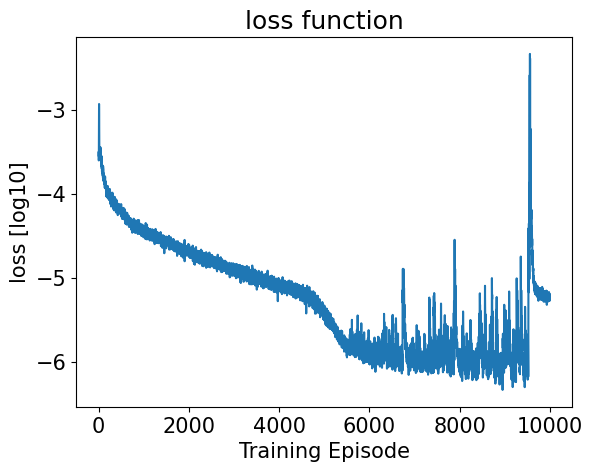

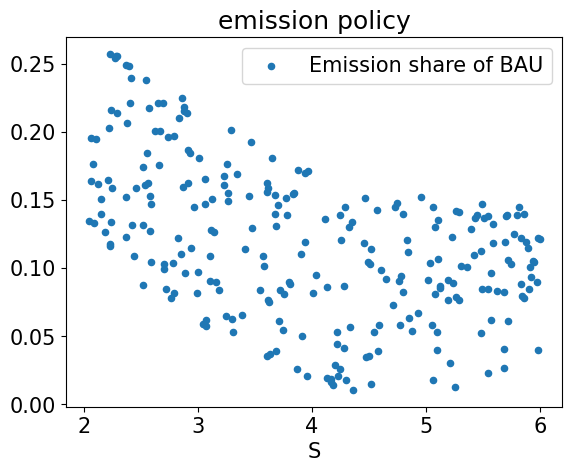

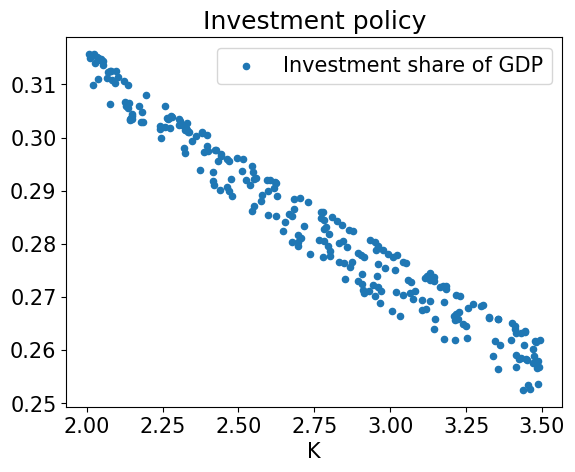

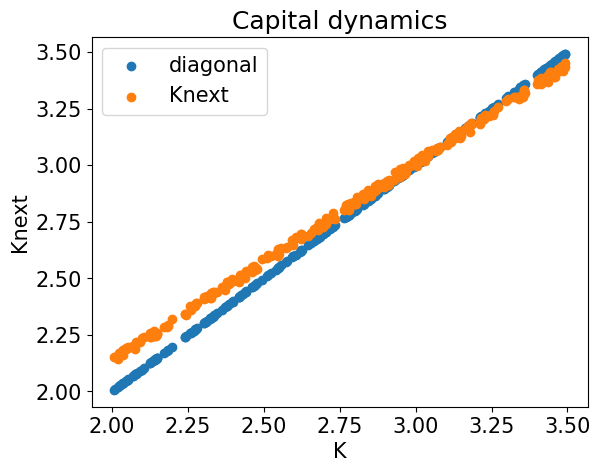

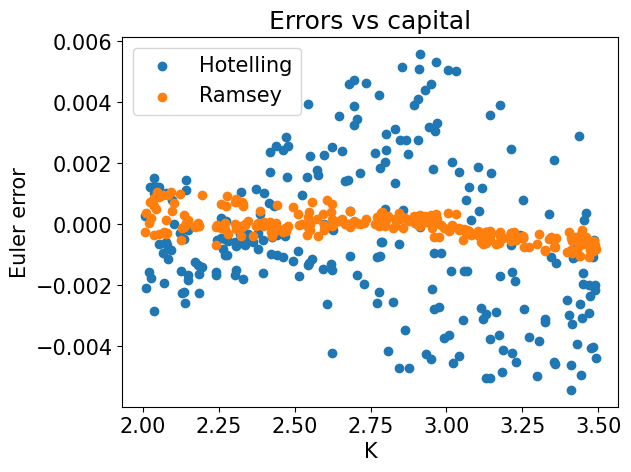

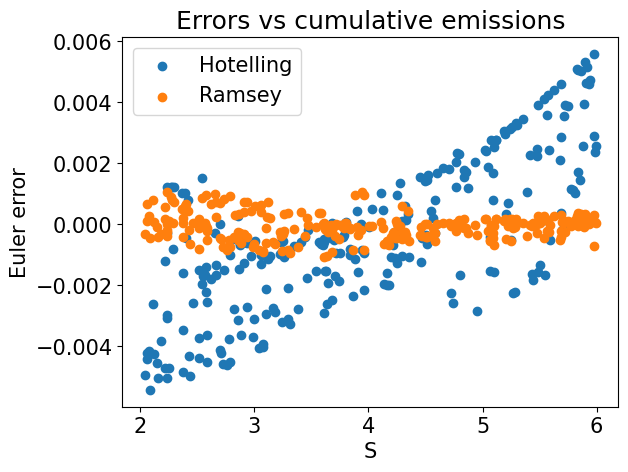

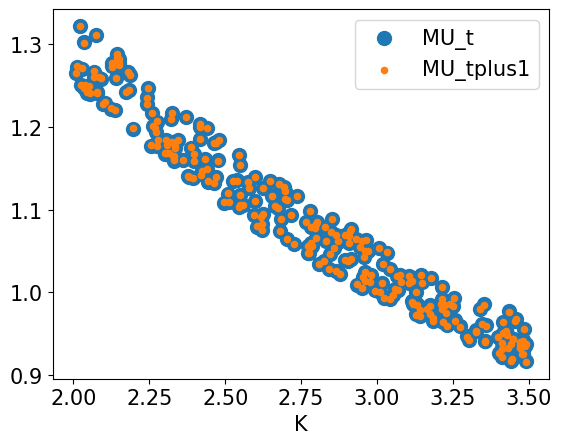

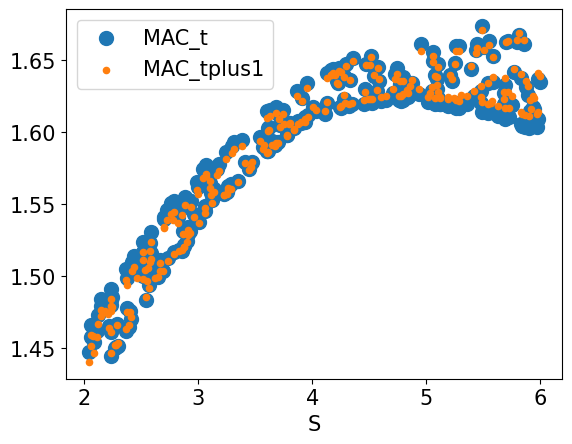

In [12]:
cost, errRamsey, errSCC, Yy, Isharey, Esharey, MU_t, MU_tplus1 , MAC_t, MAC_tplus1 = compute_cost(X, nn)
Knext = Isharey * Yy + (1-delta_c-g) * X[:,1:2]  # using X[:,1] gives a one-dimensional vector and results in a 256*256 matrix, I don't know why


plt.title("loss function")
plt.plot(np.log10(np.array(train_loss[5:])))
plt.xlabel("Training Episode")
plt.ylabel("loss [log10]")
plt.show()
plt.close()


plt.title("emission policy")
plt.xlabel("S")
plt.scatter(X[:, 0], Esharey, s = 20, label="Emission share of BAU")
plt.legend()
plt.show()
plt.close()

plt.title("Investment policy")
plt.xlabel("K")
plt.scatter(X[:, 1], Isharey, s = 20, label="Investment share of GDP")
plt.legend()
plt.show()
plt.close()

plt.title("Capital dynamics")
plt.xlabel("K")
plt.ylabel("Knext")
plt.scatter(X[:, 1], X[:, 1], label = "diagonal")
plt.scatter(X[:, 1], Knext, label = "Knext")
plt.legend()
plt.show()
plt.close()

plt.title("Errors vs capital")
plt.xlabel("K")
plt.ylabel("Euler error")
plt.scatter(X[:, 1], errSCC[:, 0], label="Hotelling")
plt.scatter(X[:, 1], errRamsey[:, 0], label="Ramsey")
plt.legend()
plt.show()
plt.close()

plt.title("Errors vs cumulative emissions")
plt.xlabel("S")
plt.ylabel("Euler error")
plt.scatter(X[:, 0], errSCC[:, 0], label="Hotelling")
plt.scatter(X[:, 0], errRamsey[:, 0], label="Ramsey")
plt.legend()
plt.show()
plt.close()

plt.xlabel("Ramsey equation")
plt.scatter(X[:, 1], MU_t[:, 0], s = 100, label="MU_t")
plt.scatter(X[:, 1], MU_tplus1[:, 0], s = 20, label="MU_tplus1")
plt.legend()
plt.xlabel("K")
plt.show()
plt.close()

plt.xlabel("Hotelling equation")
plt.scatter(X[:, 0], MAC_t[:, 0], s = 100, label="MAC_t")
plt.scatter(X[:, 0], MAC_tplus1[:, 0], s = 20, label="MAC_tplus1")
plt.legend()
plt.xlabel("S")
plt.show()
plt.close()

### Try again with simulation

In [13]:
@tf.function
def simulate_single_step(X, eps_tplus1, nn):
    # function simulates the economy one step forward based on the neural network policy and the innovation

    n_data = X.shape[0]    # number of states is on the axis 0 (FV: number of stochastic realizations )
    dim_state = X.shape[1] # dimensionality of the state is on axis 1

    # read out the state
    Sx = X[:, 0 : 1]
    Kx = X[:, 1 : 2]

    # use the neural network to predict the optimal emissions and investment
    Y = nn(X)

    # read out Y
    Esharey = Y[:, 0 : 1]
    Isharey = Y[:, 1 : 2]

    # compute Emissions, production & Investment today
    Ey = Esharey * E0
    Yy = Kx ** alpha * tf.math.exp(phi*Ey-varphi/2*Ey**2-gamma/2*Sx**2)
    Iy = Isharey * Yy

    # innovation to the AR(1)
    innovation_Ei = eps_tplus1[:,0, tf.newaxis]
    #innovation_Ii = eps_tplus1[:,1, tf.newaxis]

    # construct exogenous states at t+1
    Sx_next = Sx + Ey + innovation_Ei
    Kx_next = Iy + (1-delta_c-g) * Kx

    # construct the next step
    X_next = tf.concat([Sx_next, Kx_next],axis = 1)

    return X_next

def sim_periods(X_start, nn, num_periods):
    n_tracks = X_start.shape[0] # number of states is on the axis 0 (FV number of stochastic realizations)
    dim_state = X_start.shape[1] # dimensionality of the state is on axis 1

    # create an empty array to store the states
    X_simulation = np.empty((num_periods, n_tracks, dim_state)) # 0 axis: time period, 1 axis: the different trajectories, 2 axis: the different state variables

    # draw random innovation
    eps = tf.random.normal((num_periods, n_tracks,2), dtype = tf.float32) # number of shocks hard coded (FV: I could set this to 1 dim, but not a requirement)

    # set starting state
    X_simulation[0, :, :] = X_start

    X_old = X_start

    # simulate the periods
    for t in range(1, num_periods):
        eps_use = eps[t, :, :] # newaxis makes sure the shape is n_tracks x n_shocks (n_tracks x 2)

        X_new = simulate_single_step(X_old, eps_use, nn)

        X_simulation[t, :, :] = X_new

        X_old = X_new

    return X_simulation


def get_training_data_simulation(X_start, nn, n_periods):
    n_tracks = X_start.shape[0]
    n_dim = X_start.shape[1]

    # we simulate the model
    X_simulation = sim_periods(X_start, nn, n_periods)

    # we read out the last state (so that we can use it as starting point for the next simulation)
    X_end = np.float32(X_simulation[-1, :, :])

    # we reshape the data into (n_tracks * n_periods) x 2 array
    X_training = np.float32(np.reshape(X_simulation, (n_tracks * n_periods, n_dim)))

    return X_training, X_end

In [14]:
#Let's get a new neural network
Inlayer = keras.Input(shape=(num_input,))
hidden1 = keras.layers.Dense(num_hidden1, activation='selu')(Inlayer)
hidden2 = keras.layers.Dense(num_hidden2, activation='selu')(hidden1)
neuronE = keras.layers.Dense(1, activation = "linear")(hidden2)
neuronI = keras.layers.Dense(1, activation = "sigmoid")(hidden2)
outlayer = keras.layers.concatenate([neuronE, neuronI])

nn2 = keras.Model(inputs=Inlayer, outputs=outlayer)
nn2.build(input_shape=(None, num_input))

In [15]:

n_tracks = 256
n_periods = 1
print("n_tracks = ", n_tracks)
print("n_periods = ", n_periods)

# start from a random state
X_start = get_training_data(S_lb, S_ub, k_lb, k_ub, n_tracks)
print("X_start.shape = ", X_start.shape)
print("With every simulation we get", n_tracks * n_periods, "new states")
#print("X_start",X_start[0,:])

X_training, X_end = get_training_data_simulation(X_start, nn2, n_periods)
print("X_training.shape = ", X_training.shape)
print("X_end.shape = ", X_end.shape)
#print("X_end",X_end[0,:])
learning_rate = 1e-4
print("learning_rate = ", learning_rate)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

print(compute_cost(X_start, nn2)[0])

n_tracks =  256
n_periods =  1
X_start.shape =  (256, 2)
With every simulation we get 256 new states
X_training.shape =  (256, 2)
X_end.shape =  (256, 2)
learning_rate =  0.0001
tf.Tensor(0.09211669, shape=(), dtype=float32)


In [16]:
# Keep results for plotting
train_loss = []

num_episodes = 5001

# initialize X_start
X_start = X_end
print("n_tracks = ", X_start.shape[0])
print("n_periods = ", n_periods)

for ep in range(num_episodes):
    # generate training data, now by sampling
    X, X_end = get_training_data_simulation(X_start, nn2, n_periods)

    # update X_start
    X_start = X_end

    # compute loss and gradients
    loss, grads = grad(X, nn2)

    # apply gradients
    optimizer.apply_gradients(zip(grads, nn2.trainable_variables))

    # record loss
    train_loss.append(loss.numpy())

    # print progress
    if ep % int(0.1 * num_episodes) == 0:
        print("#=================================================================")
        print("episode = {}, loss [log10] = {}".format(ep, np.log10(loss.numpy())))

n_tracks =  256
n_periods =  1
#=================================================================
episode = 0, loss [log10] = -1.0356616973876953
#=================================================================
episode = 500, loss [log10] = -4.4436774253845215
#=================================================================
episode = 1000, loss [log10] = -4.657684803009033
#=================================================================
episode = 1500, loss [log10] = -4.779253959655762
#=================================================================
episode = 2000, loss [log10] = -4.864935398101807
#=================================================================
episode = 2500, loss [log10] = -4.921359539031982
#=================================================================
episode = 3000, loss [log10] = -4.9701995849609375
#=================================================================
episode = 3500, loss [log10] = -5.024842262268066
#=================================

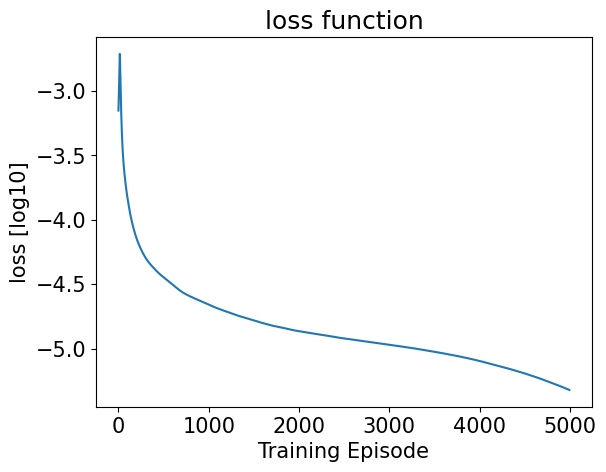

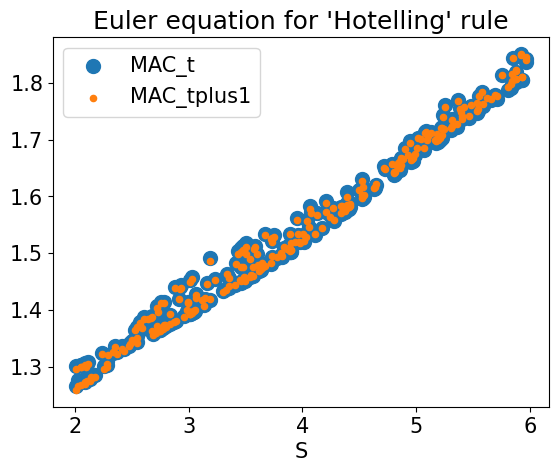

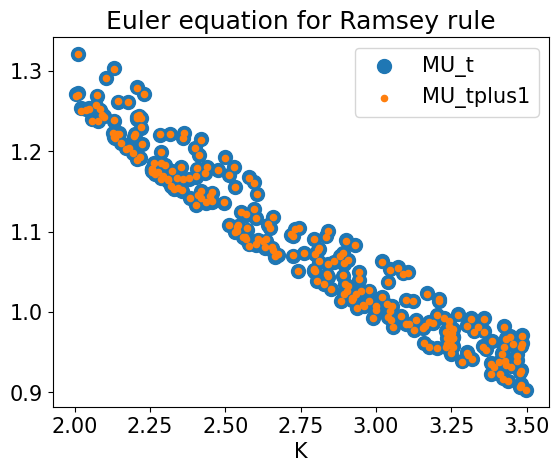

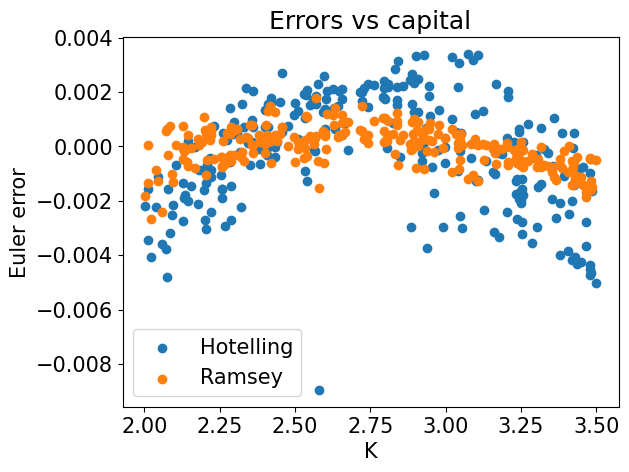

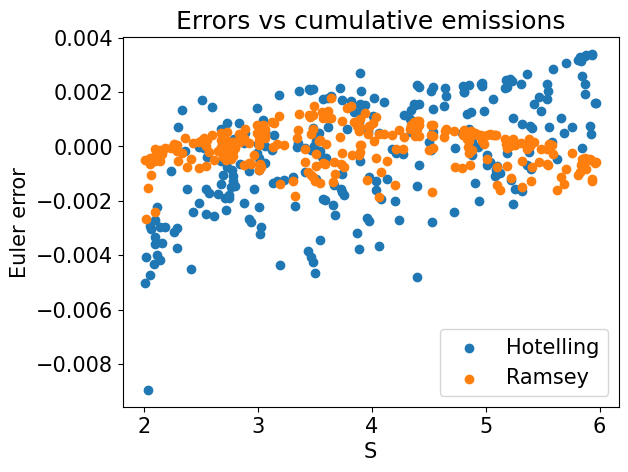

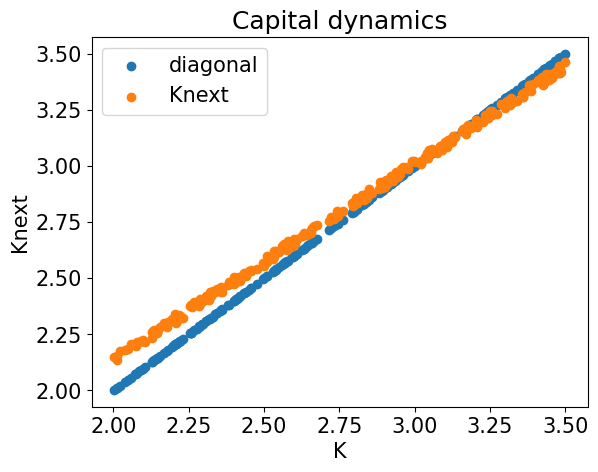

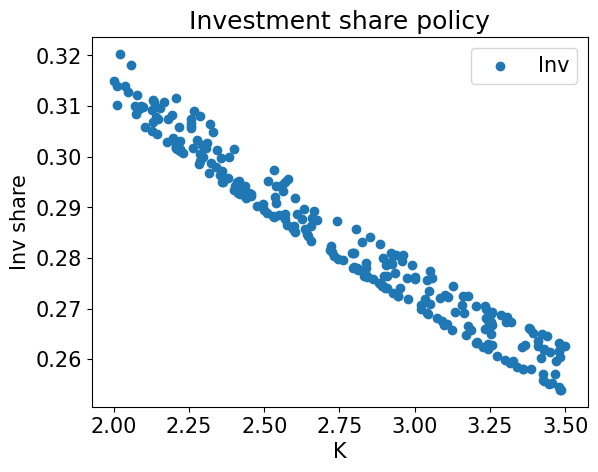

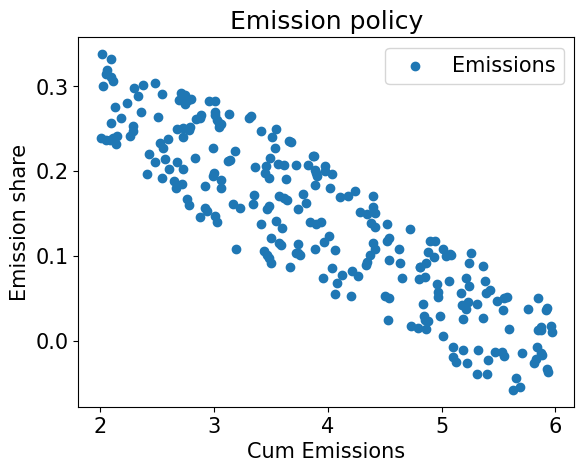

In [17]:
cost, errRamsey, errSCC, Yy, Isharey, Esharey, MU_t, MU_tplus1,MAC_t,MAC_tplus1 = compute_cost(X, nn2)

plt.title("loss function")
plt.plot(np.log10(np.array(train_loss[5:])))
plt.xlabel("Training Episode")
plt.ylabel("loss [log10]")
plt.show()
plt.close()

plt.title("Euler equation for 'Hotelling' rule")
plt.scatter(X[:, 0], MAC_t[:, 0], s = 100, label="MAC_t")
plt.scatter(X[:, 0], MAC_tplus1[:, 0], s = 20, label="MAC_tplus1")
plt.legend()
plt.xlabel("S")
plt.show()
plt.close()

plt.title("Euler equation for Ramsey rule")
plt.scatter(X[:, 1], MU_t[:, 0], s = 100, label="MU_t")
plt.scatter(X[:, 1], MU_tplus1[:, 0], s = 20, label="MU_tplus1")
plt.legend()
plt.xlabel("K")
plt.show()
plt.close()

plt.title("Errors vs capital")
plt.xlabel("K")
plt.ylabel("Euler error")
plt.scatter(X[:, 1], errSCC[:, 0], label="Hotelling")
plt.scatter(X[:, 1], errRamsey[:, 0], label="Ramsey")
plt.legend()
plt.show()
plt.close()

plt.title("Errors vs cumulative emissions")
plt.xlabel("S")
plt.ylabel("Euler error")
plt.scatter(X[:, 0], errSCC[:, 0], label="Hotelling")
plt.scatter(X[:, 0], errRamsey[:, 0], label="Ramsey")
plt.legend()
plt.show()
plt.close()


#policy_guess = nn2(X)
#Ey = policy_guess[:,0] * E0
#Output =  X[:,1] ** alpha * tf.math.exp(phi*Ey - varphi/2*Ey**2 - gamma/2*X[:,0]**2)
#Iy = policy_guess[:,1] * Output
#Knext = Iy + (1-delta_c-g) * X[:,1]
Knext = Isharey * Yy + (1-delta_c-g) * X[:,1:2]
plt.title("Capital dynamics")
plt.xlabel("K")
plt.ylabel("Knext")
plt.scatter(X[:, 1], X[:, 1], label = "diagonal")
plt.scatter(X[:, 1], Knext, label = "Knext")
plt.legend()
plt.show()
plt.close()

plt.title("Investment share policy")
plt.xlabel("K")
plt.ylabel("Inv share")
plt.scatter(X[:, 1], Isharey, label = "Inv")
plt.legend()
plt.show()
plt.close()

plt.title("Emission policy")
plt.xlabel("Cum Emissions")
plt.ylabel("Emission share")
plt.scatter(X[:, 0], Esharey, label = "Emissions")
plt.legend()
plt.show()
plt.close()
